# Detecção de Deepfakes – Comparação de Modelos
## Metodologia CRISP-DM

**Dataset 1:** [Deepfake and Real Images](https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images) (Kaggle)  
**Dataset 2:** [Deepfake vs Real 60k](https://www.kaggle.com/datasets/prithivsakthiur/deepfake-vs-real-60k) (Kaggle)

**Objetivo:** Classificar imagens como **reais** ou **deepfake** usando técnicas de aprendizado de máquina.

### Fases do CRISP-DM:
1. **Business Understanding** – Entender o problema (detecção de fake news visuais).
2. **Data Understanding** – Explorar a distribuição e qualidade das imagens.
3. **Data Preparation** – Redimensionar, normalizar e dividir os dados.
4. **Modeling** – Treinar e ajustar modelos (CNN, ResNet50 + RF/XGBoost/MLP).
5. **Evaluation** – Comparar métricas (acurácia, precisão, recall, F1, matriz de confusão, ROC).
6. **Deployment** – Salvar modelos e gerar relatório final.

## 1. Setup e Configurações

In [1]:
# Instalação de pacotes necessários
!pip install kagglehub tensorflow scikit-learn xgboost seaborn matplotlib tqdm pillow torch torchvision -q

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub

from pathlib import Path
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import joblib

# PyTorch para ResNet50
import torch
import torch.nn as nn
from torchvision import transforms, models

warnings.filterwarnings('ignore')

# Configuração do dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo PyTorch: {device}")

Dispositivo PyTorch: cuda


In [3]:
# Configurações globais
IMG_SIZE_CNN = (64, 64)      # Tamanho para a CNN
IMG_SIZE_RESNET = (224, 224) # Tamanho para a ResNet50
CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 10
RANDOM_STATE = 42
MAX_SAMPLES = 2000           # Amostras por classe

# Seleção do dataset (True = Dataset 1, False = Dataset 2)
USE_DATASET = False  # Altere para False para usar o dataset de 60k

# Reproducibilidade
np.random.seed(RANDOM_STATE)
import tensorflow as tf
tf.random.set_seed(RANDOM_STATE)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
torch.manual_seed(RANDOM_STATE)

## 2. Business Understanding

Deepfakes são vídeos/imagens gerados por IA que podem espalhar desinformação. O objetivo é construir um classificador binário (Real vs Fake). Serão comparados:
- **Modelo profundo (CNN)**: treinado do zero
- **ResNet50 + Classificadores**: extração de features com ResNet50 pré-treinada + Random Forest, XGBoost, MLP

## 3. Data Understanding

### 3.1 Download e exploração inicial do dataset

In [4]:
# Download do dataset selecionado
if USE_DATASET:
    try:
        dataset_path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")
        print(f"Dataset 1 baixado em: {dataset_path}")
    except Exception as e:
        print(f"Erro no download do dataset : {e}")
        dataset_path = input("Caminho da pasta do dataset 1: ")
else:
    try:
        dataset_path = kagglehub.dataset_download("prithivsakthiur/deepfake-vs-real-60k")
        print(f"Dataset 2 baixado em: {dataset_path}")
    except Exception as e:
        print(f"Erro no download do dataset 2: {e}")
        dataset_path = input("Caminho da pasta do dataset 2: ")

100%|██████████| 22.4G/22.4G [04:30<00:00, 89.0MB/s]


Extracting files...
Dataset 2 baixado em: /root/.cache/kagglehub/datasets/prithivsakthiur/deepfake-vs-real-60k/versions/1


In [16]:
def find_directories_any(base_path):
    base = Path(base_path)
    real_dirs = []
    fake_dirs = []

    # Procura recursivamente por pastas com nome exato 'real' ou 'fake' (case-insensitive)
    for p in base.rglob("*"):
        if p.is_dir():
            name = p.name.lower()
            if name == "real":
                real_dirs.append(p)
            elif name == "fake":
                fake_dirs.append(p)

    # Se não encontrou, procura por pastas que contenham 'real' ou 'fake' no nome
    if not real_dirs and not fake_dirs:
        for p in base.rglob("*"):
            if p.is_dir():
                name = p.name.lower()
                if "real" in name:
                    real_dirs.append(p)
                elif "fake" in name:
                    fake_dirs.append(p)

    # Remove duplicatas e garante que contenham arquivos de imagem
    image_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    def has_images(d):
        try:
            return any(f.suffix.lower() in image_ext for f in d.iterdir())
        except:
            return False

    real_dirs = list({str(d) for d in real_dirs if has_images(d)})
    fake_dirs = list({str(d) for d in fake_dirs if has_images(d)})
    real_dirs = [Path(d) for d in real_dirs]
    fake_dirs = [Path(d) for d in fake_dirs]

    return real_dirs, fake_dirs

In [19]:
real_dirs, fake_dirs = find_directories_any(dataset_path)
print(f"Real dirs: {real_dirs}")
print(f"Fake dirs: {fake_dirs}")

Real dirs: [PosixPath('/root/.cache/kagglehub/datasets/prithivsakthiur/deepfake-vs-real-60k/versions/1/deepfake-vs-real-60k/Real')]
Fake dirs: [PosixPath('/root/.cache/kagglehub/datasets/prithivsakthiur/deepfake-vs-real-60k/versions/1/deepfake-vs-real-60k/Fake')]


## 4. Data Preparation

### 4.1 Carregamento e pré-processamento das imagens

In [18]:
def load_images_from_dirs(directories, label, img_size, max_samples=MAX_SAMPLES):
    """Carrega imagens de uma lista de diretórios"""
    images, labels = [], []
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    total_loaded = 0

    for dir_path in directories:
        files = [f for f in Path(dir_path).iterdir() if f.suffix.lower() in extensions]
        print(f"  → {dir_path.name}: {len(files)} imagens")

        for file in tqdm(files[:max_samples - total_loaded], desc=f"Carregando {dir_path.name}"):
            try:
                img = Image.open(file).convert("RGB").resize(img_size)
                images.append(np.array(img))
                labels.append(label)
                total_loaded += 1
            except Exception:
                pass
        if total_loaded >= max_samples:
            break
    return images[:max_samples], labels[:max_samples]

def load_dataset(base_path, img_size):
    """Carrega todo o dataset"""
    print("\n[1/4] Localizando diretórios...")
    if USE_DATASET:
        real_dirs, fake_dirs = find_directories_any(base_path)
    else:
        real_dirs, fake_dirs = find_directories_any(base_path)

    if not real_dirs and not fake_dirs:
        base = Path(base_path)
        real_dirs = [base / "real"] if (base / "real").exists() else []
        fake_dirs = [base / "fake"] if (base / "fake").exists() else []

    print(f"[2/4] Carregando imagens REAL (label=1)...")
    real_imgs, real_labels = load_images_from_dirs(real_dirs, label=1, img_size=img_size)
    print(f"[3/4] Carregando imagens FAKE (label=0)...")
    fake_imgs, fake_labels = load_images_from_dirs(fake_dirs, label=0, img_size=img_size)

    X = np.array(real_imgs + fake_imgs, dtype=np.float32) / 255.0
    y = np.array(real_labels + fake_labels, dtype=np.int32)

    print(f"\nTotal: Real={len(real_imgs)}, Fake={len(fake_imgs)}")
    return X, y

# Carregar dataset para CNN (64x64)
X_cnn, y_cnn = load_dataset(dataset_path, IMG_SIZE_CNN)
print(f"Dataset CNN shape: {X_cnn.shape}, labels: {y_cnn.shape}")
print(f"Distribuição: Real={np.sum(y_cnn)}, Fake={len(y_cnn)-np.sum(y_cnn)}")

# Carregar dataset para ResNet50 (224x224)
X_resnet, y_resnet = load_dataset(dataset_path, IMG_SIZE_RESNET)
print(f"Dataset ResNet50 shape: {X_resnet.shape}, labels: {y_resnet.shape}")


[1/4] Localizando diretórios...
[2/4] Carregando imagens REAL (label=1)...
  → Real: 28475 imagens


Carregando Real: 100%|██████████| 2000/2000 [00:35<00:00, 56.85it/s]


[3/4] Carregando imagens FAKE (label=0)...
  → Fake: 28596 imagens


Carregando Fake: 100%|██████████| 2000/2000 [01:11<00:00, 27.79it/s]



Total: Real=2000, Fake=2000
Dataset CNN shape: (4000, 64, 64, 3), labels: (4000,)
Distribuição: Real=2000, Fake=2000

[1/4] Localizando diretórios...
[2/4] Carregando imagens REAL (label=1)...
  → Real: 28475 imagens


Carregando Real: 100%|██████████| 2000/2000 [00:28<00:00, 70.26it/s]


[3/4] Carregando imagens FAKE (label=0)...
  → Fake: 28596 imagens


Carregando Fake: 100%|██████████| 2000/2000 [01:08<00:00, 29.27it/s]



Total: Real=2000, Fake=2000
Dataset ResNet50 shape: (4000, 224, 224, 3), labels: (4000,)


### 4.2 Visualização de amostras

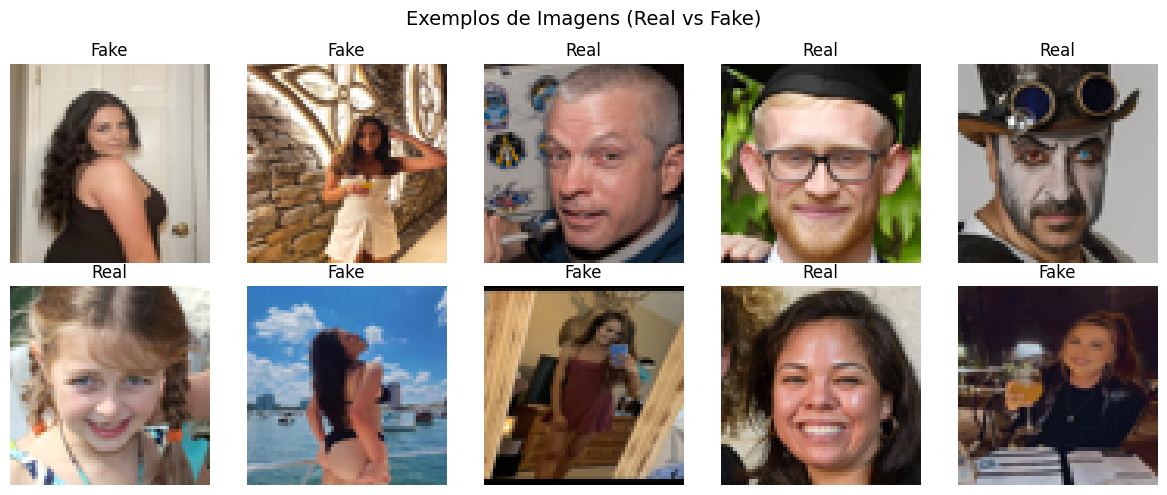

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_cnn))
    ax.imshow(X_cnn[idx])
    ax.set_title("Real" if y_cnn[idx]==1 else "Fake")
    ax.axis("off")
plt.suptitle("Exemplos de Imagens (Real vs Fake)", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Divisão treino/teste (80/20) com estratificação para CNN
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cnn
)

# Divisão para ResNet50
X_train_resnet, X_test_resnet, y_train_resnet, y_test_resnet = train_test_split(
    X_resnet, y_resnet, test_size=0.2, random_state=RANDOM_STATE, stratify=y_resnet
)

print(f"CNN - Treino: {X_train_cnn.shape[0]} amostras, Teste: {X_test_cnn.shape[0]} amostras")
print(f"ResNet50 - Treino: {X_train_resnet.shape[0]} amostras, Teste: {X_test_resnet.shape[0]} amostras")

CNN - Treino: 3200 amostras, Teste: 800 amostras
ResNet50 - Treino: 3200 amostras, Teste: 800 amostras


## 5. Modelagem e Avaliação

### 5.1 Funções auxiliares

In [22]:
results = {}

def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Avalia e armazena métricas do modelo"""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred,
    }
    if y_prob is not None:
        metrics["auc"] = roc_auc_score(y_true, y_prob)
    results[name] = metrics

    print(f"\n{'='*50}")
    print(f"  MODELO: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    if "auc" in metrics:
        print(f"  ROC-AUC:   {metrics['auc']:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))
    return metrics

def plot_confusion_matrix(name, cm):
    """Plota matriz de confusão"""
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
    plt.title(f"{name} - Matriz de Confusão", fontweight='bold', fontsize=14)
    plt.ylabel("Verdadeiro")
    plt.xlabel("Previsto")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{name.lower().replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

### 5.2 Modelo 1: CNN (Rede Neural Convolucional) - Treinada do Zero

In [23]:
def create_cnn(input_shape):
    """Cria modelo CNN"""
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("\n" + "="*60)
print("MODELO 1 — CNN")
print("="*60)

cnn = create_cnn((*IMG_SIZE_CNN, CHANNELS))
cnn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn = cnn.fit(
    X_train_cnn, y_train_cnn,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred_cnn_prob = cnn.predict(X_test_cnn, verbose=0).flatten()
y_pred_cnn = (y_pred_cnn_prob >= 0.5).astype(int)
metrics_cnn = evaluate_model("CNN (Treinada)", y_test_cnn, y_pred_cnn, y_pred_cnn_prob)


MODELO 1 — CNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,191,809 (8.36 MB)

 Trainable params: 2,191,361 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9292 - loss: 0.3254 - val_accuracy: 0.7594 - val_loss: 0.4868
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9906 - loss: 0.0356 - val_accuracy: 0.5250 - val_loss: 2.2056
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9920 - loss: 0.0290 - val_accuracy: 0.5094 - val_loss: 3.0557
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9872 - loss: 0.0580 - val_accuracy: 0.8188 - val_loss: 0.8143

  MODELO: CNN (Treinada)
  Accuracy:  0.7688
  Precision: 0.6870
  Recall:    0.9875
  F1-Score:  0.8103
  ROC-AUC:   0.9478

Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.55      0.70       400
        Real       0.69      0.99      0.81       400

    accuracy                           0.77       800
   macro avg       0.83      0.77      0.76       800
weighted avg       0.83      0.77      0.76       800



### 5.3 Extração de Features com ResNet50 (PyTorch)

In [24]:
print("\n" + "="*60)
print("EXTRAÇÃO DE FEATURES COM RESNET50")
print("="*60)

# Carregar ResNet50 pré-treinada sem a camada de classificação final
resnet50 = models.resnet50(pretrained=True)
num_features = resnet50.fc.in_features  # 2048
resnet50.fc = nn.Identity()  # Remove a camada fully connected
resnet50 = resnet50.to(device)
resnet50.eval()

print(f"Dimensão das features extraídas: {num_features}")

# Transformações para a ResNet50
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def extract_features(images, batch_size=32):
    """Extrai features usando ResNet50"""
    features_list = []

    with torch.no_grad():
        for i in tqdm(range(0, len(images), batch_size), desc="Extraindo features"):
            batch = images[i:i+batch_size]
            batch_tensor = torch.stack([transform(Image.fromarray((img*255).astype(np.uint8)))
                                        for img in batch])
            batch_tensor = batch_tensor.to(device)

            batch_features = resnet50(batch_tensor).cpu().numpy()
            features_list.append(batch_features)

    return np.vstack(features_list)

# Extrair features
print("\nExtraindo features do TREINO...")
X_train_features = extract_features(X_train_resnet)

print("\nExtraindo features do TESTE...")
X_test_features = extract_features(X_test_resnet)

print(f"Features shape: Treino={X_train_features.shape}, Teste={X_test_features.shape}")


EXTRAÇÃO DE FEATURES COM RESNET50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


Dimensão das features extraídas: 2048

Extraindo features do TREINO...


Extraindo features: 100%|██████████| 100/100 [00:16<00:00,  6.07it/s]



Extraindo features do TESTE...


Extraindo features: 100%|██████████| 25/25 [00:03<00:00,  6.41it/s]

Features shape: Treino=(3200, 2048), Teste=(800, 2048)


### 5.4 Modelo 2: Random Forest com features da ResNet50

In [25]:
print("\n" + "="*60)
print("MODELO 2 — RANDOM FOREST com ResNet50")
print("="*60)

rf_resnet = RandomForestClassifier(
    n_estimators=100, max_depth=15, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1
)
rf_resnet.fit(X_train_features, y_train_resnet)

y_pred_rf = rf_resnet.predict(X_test_features)
y_prob_rf = rf_resnet.predict_proba(X_test_features)[:, 1]
metrics_rf = evaluate_model("Random Forest + ResNet50", y_test_resnet, y_pred_rf, y_prob_rf)


MODELO 2 — RANDOM FOREST com ResNet50


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    6.6s



  MODELO: Random Forest + ResNet50
  Accuracy:  0.9700
  Precision: 0.9700
  Recall:    0.9700
  F1-Score:  0.9700
  ROC-AUC:   0.9975

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.97      0.97       400
        Real       0.97      0.97      0.97       400

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   12.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


### 5.5 Modelo 3: XGBoost com features da ResNet50

In [26]:
print("\n" + "="*60)
print("MODELO 3 — XGBOOST com ResNet50")
print("="*60)

xgb_resnet = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=1
)

xgb_resnet.fit(
    X_train_features, y_train_resnet,
    eval_set=[(X_test_features, y_test_resnet)],
    verbose=False
)

y_pred_xgb = xgb_resnet.predict(X_test_features)
y_prob_xgb = xgb_resnet.predict_proba(X_test_features)[:, 1]
metrics_xgb = evaluate_model("XGBoost + ResNet50", y_test_resnet, y_pred_xgb, y_prob_xgb)


MODELO 3 — XGBOOST com ResNet50

  MODELO: XGBoost + ResNet50
  Accuracy:  0.9812
  Precision: 0.9800
  Recall:    0.9825
  F1-Score:  0.9813
  ROC-AUC:   0.9989

Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.98      0.98       400
        Real       0.98      0.98      0.98       400

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



### 5.6 Modelo 4: MLP com features da ResNet50

In [27]:
print("\n" + "="*60)
print("MODELO 4 — MLP com ResNet50")
print("="*60)

mlp_resnet = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128), activation='relu',
    solver='adam', max_iter=100, early_stopping=True,
    validation_fraction=0.1, random_state=RANDOM_STATE, verbose=True
)
mlp_resnet.fit(X_train_features, y_train_resnet)

y_pred_mlp = mlp_resnet.predict(X_test_features)
y_prob_mlp = mlp_resnet.predict_proba(X_test_features)[:, 1]
metrics_mlp = evaluate_model("MLP + ResNet50", y_test_resnet, y_pred_mlp, y_prob_mlp)


MODELO 4 — MLP com ResNet50
Iteration 1, loss = 0.40702808
Validation score: 0.959375
Iteration 2, loss = 0.07693479
Validation score: 0.987500
Iteration 3, loss = 0.05007086
Validation score: 0.981250
Iteration 4, loss = 0.03087125
Validation score: 0.984375
Iteration 5, loss = 0.02614836
Validation score: 0.978125
Iteration 6, loss = 0.02317392
Validation score: 0.987500
Iteration 7, loss = 0.01594615
Validation score: 0.993750
Iteration 8, loss = 0.01179671
Validation score: 0.987500
Iteration 9, loss = 0.00859506
Validation score: 0.993750
Iteration 10, loss = 0.01080817
Validation score: 0.990625
Iteration 11, loss = 0.00681527
Validation score: 0.990625
Iteration 12, loss = 0.00591825
Validation score: 0.987500
Iteration 13, loss = 0.00198214
Validation score: 0.987500
Iteration 14, loss = 0.00138650
Validation score: 0.987500
Iteration 15, loss = 0.00099204
Validation score: 0.990625
Iteration 16, loss = 0.00075953
Validation score: 0.987500
Iteration 17, loss = 0.00064701
Vali

### 5.7 Visualização de Erros e Acertos (para o melhor modelo)


MLP + ResNet50:
  FP (Falso Positivo - Real classificado como Fake): 2
  FN (Falso Negativo - Fake classificado como Real): 11
  TP Fake: 389
  TP Real: 398


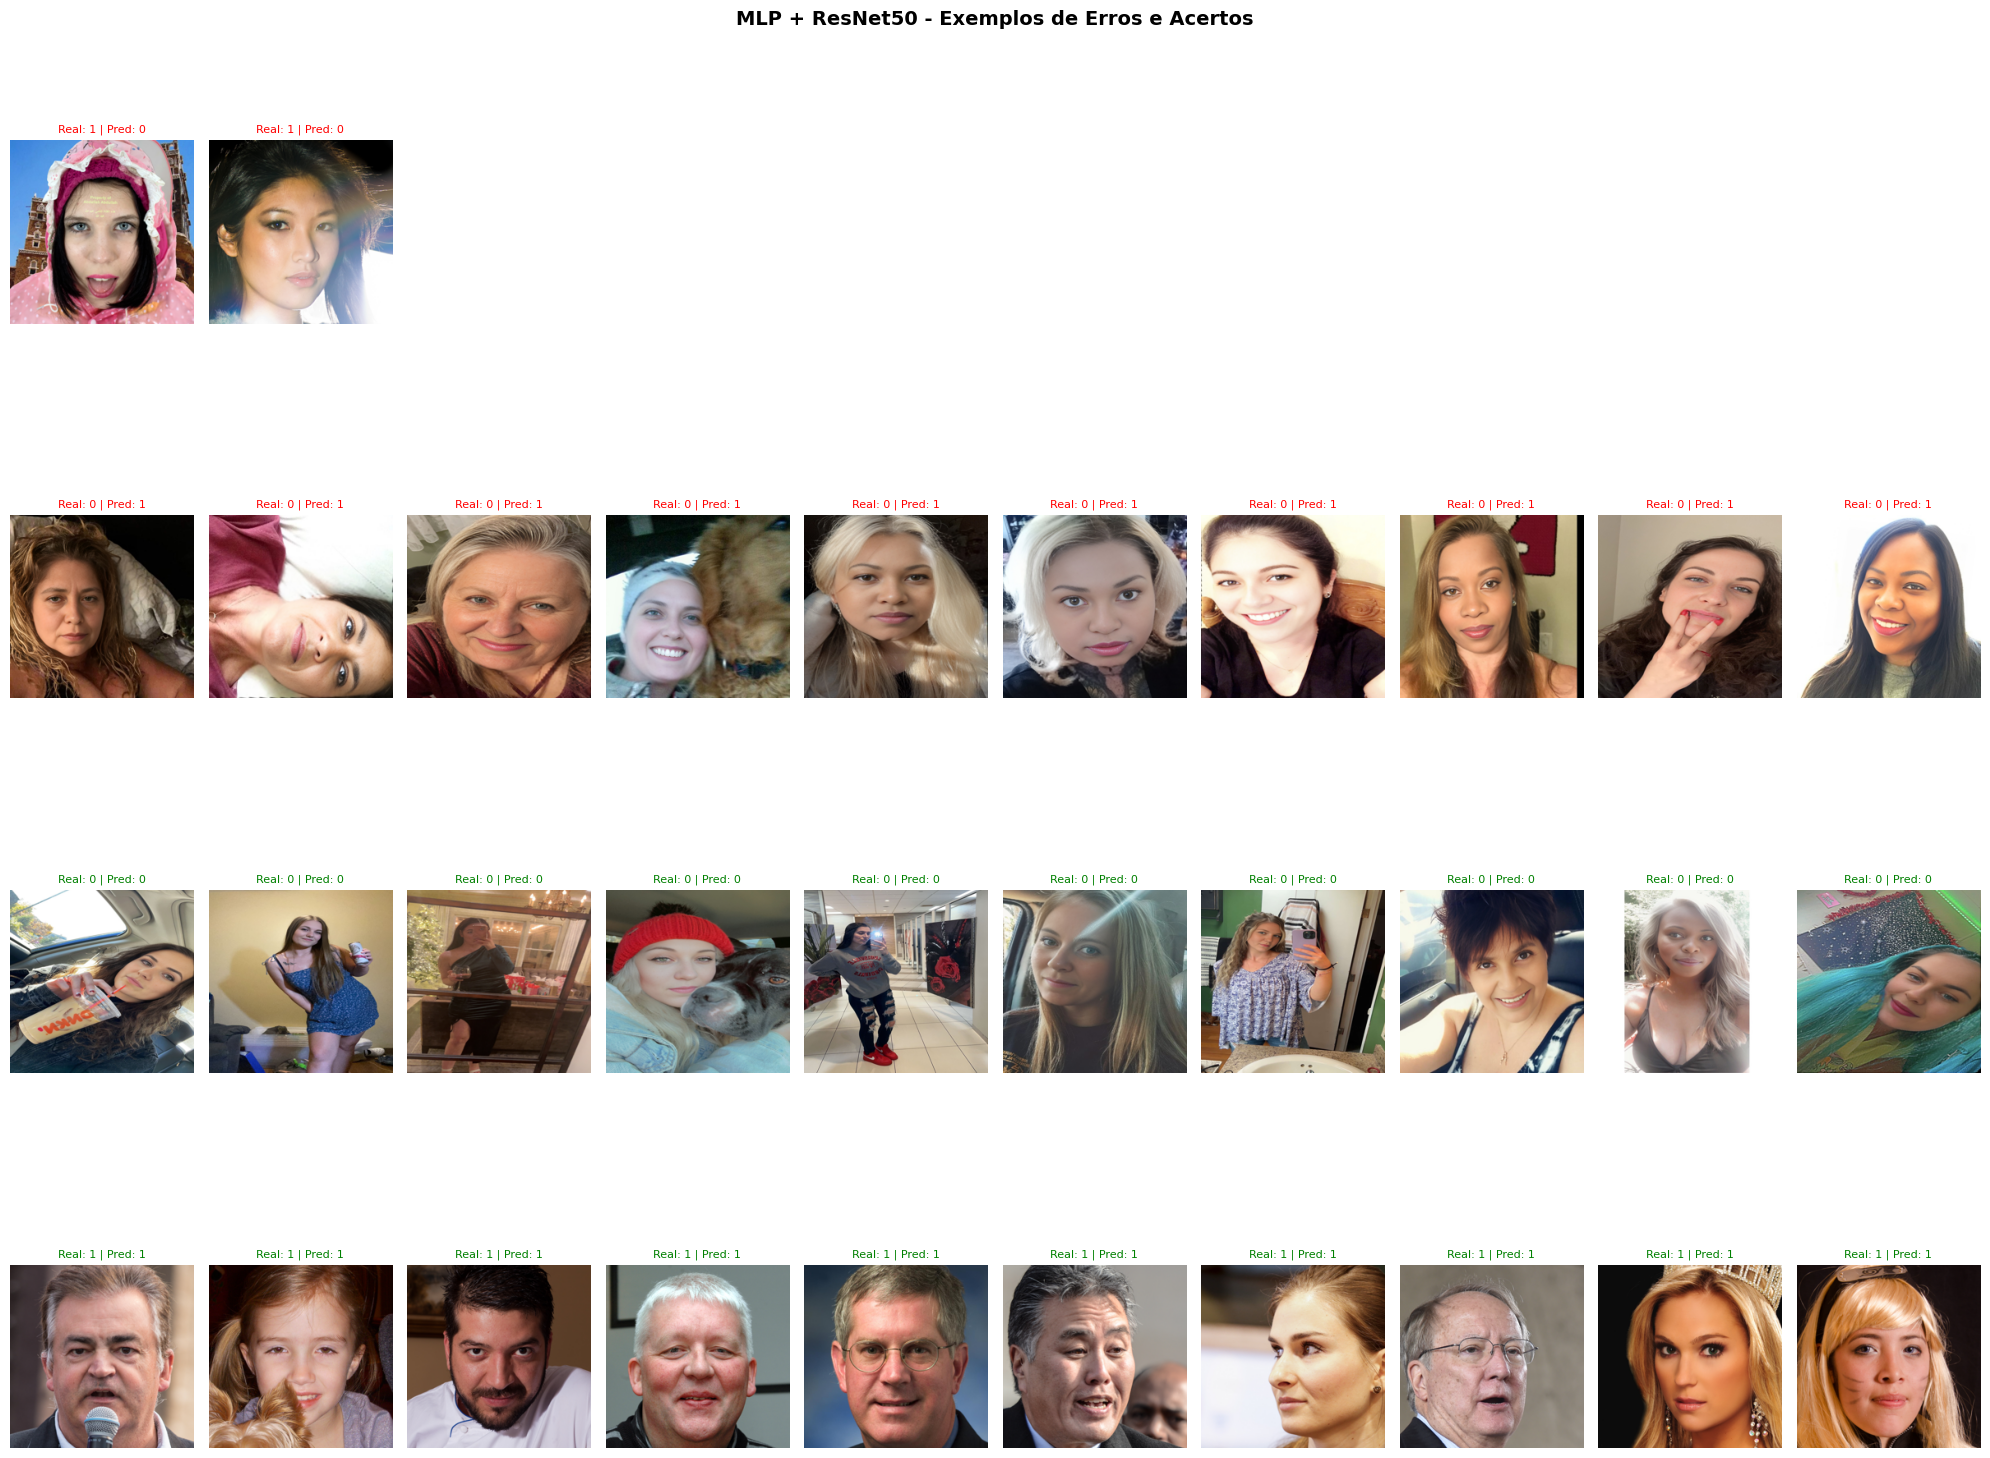

  Figura salva: erros_acertos_mlp___resnet50.png


In [32]:
def visualizar_erros_acertos(modelo_nome, y_pred, X_imgs, y_true):
    """
    Mostra 10 exemplos de cada categoria:
    - FP (Falso Positivo): predito Fake, mas é Real
    - FN (Falso Negativo): predito Real, mas é Fake
    - TP Fake (Acerto Fake): predito Fake, realmente Fake
    - TP Real (Acerto Real): predito Real, realmente Real
    """
    # Calcular índices para cada categoria
    fp_indices = np.where((y_pred == 0) & (y_true == 1))[0]
    fn_indices = np.where((y_pred == 1) & (y_true == 0))[0]
    tp_fake_indices = np.where((y_pred == 0) & (y_true == 0))[0]
    tp_real_indices = np.where((y_pred == 1) & (y_true == 1))[0]

    print(f"\n{modelo_nome}:")
    print(f"  FP (Falso Positivo - Real classificado como Fake): {len(fp_indices)}")
    print(f"  FN (Falso Negativo - Fake classificado como Real): {len(fn_indices)}")
    print(f"  TP Fake: {len(tp_fake_indices)}")
    print(f"  TP Real: {len(tp_real_indices)}")

    # Criar figura
    fig, axes = plt.subplots(4, 10, figsize=(20, 16))
    fig.suptitle(f"{modelo_nome} - Exemplos de Erros e Acertos", fontsize=14, fontweight='bold')

    categorias = [
        (fp_indices, 'FP - Falso Positivo\n(Predito Fake, Real)', 0),
        (fn_indices, 'FN - Falso Negativo\n(Predito Real, Fake)', 1),
        (tp_fake_indices, 'TP - Acerto Fake\n(Predito Fake, Fake)', 2),
        (tp_real_indices, 'TP - Acerto Real\n(Predito Real, Real)', 3)
    ]

    for row, (indices, titulo, cat_id) in enumerate(categorias):
        n_amostras = min(10, len(indices))
        indices_plot = np.random.choice(indices, n_amostras, replace=False) if n_amostras > 0 else []

        for col in range(10):
            ax = axes[row, col]
            if col < n_amostras and len(indices_plot) > 0:
                idx = indices_plot[col]
                img = X_imgs[idx]
                ax.imshow(img)
                if row < 2:  # Erros
                    ax.set_title(f"Real: {y_true[idx]} | Pred: {y_pred[idx]}",
                                color='red', fontsize=8)
                else:  # Acertos
                    ax.set_title(f"Real: {y_true[idx]} | Pred: {y_pred[idx]}",
                                color='green', fontsize=8)
            else:
                ax.axis('off')
            ax.axis('off')

        axes[row, 0].set_ylabel(titulo, fontsize=9, rotation=90, labelpad=40)

    plt.tight_layout()
    filename = f"erros_acertos_{modelo_nome.lower().replace(' ', '_').replace('+', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Figura salva: {filename}")

# Usar o melhor modelo (XGBoost com ResNet50)
melhor_modelo_resnet = 'MLP + ResNet50'
visualizar_erros_acertos(
    melhor_modelo_resnet,
    results[melhor_modelo_resnet]['y_pred'],
    X_test_resnet,
    y_test_resnet
)

## 6. Comparação Final e Visualizações

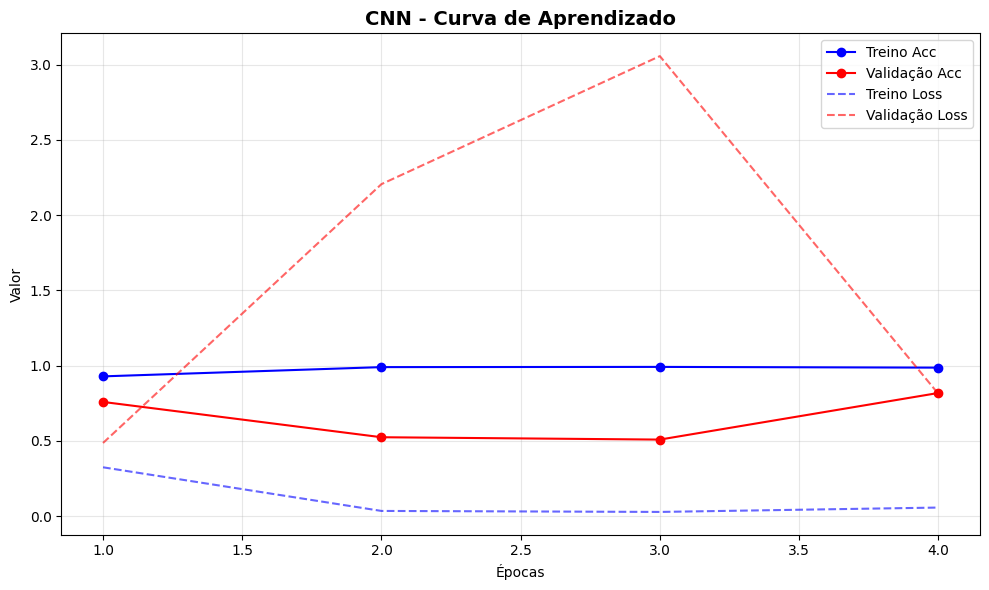

Curva de aprendizado salva como 'cnn_learning_curve.png'


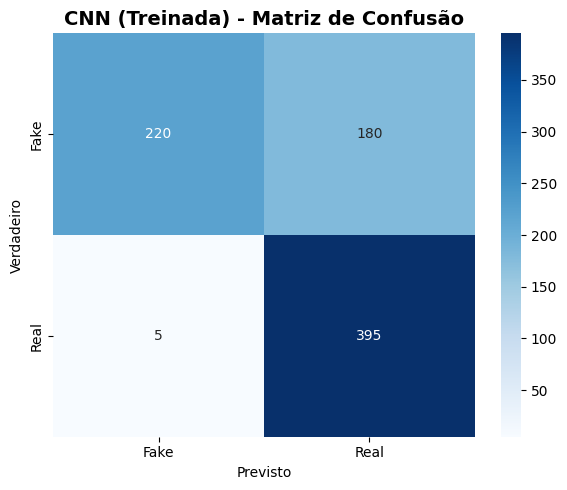

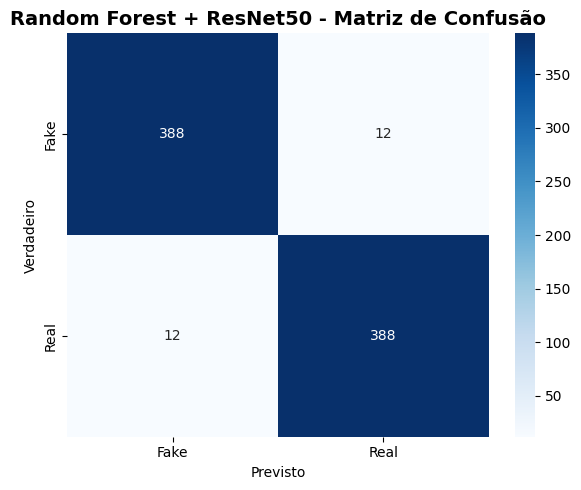

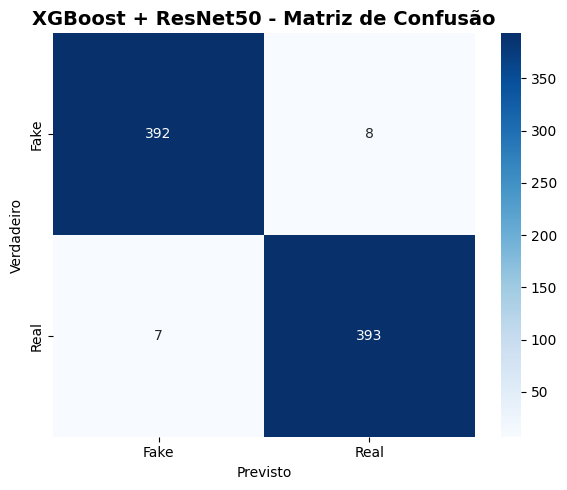

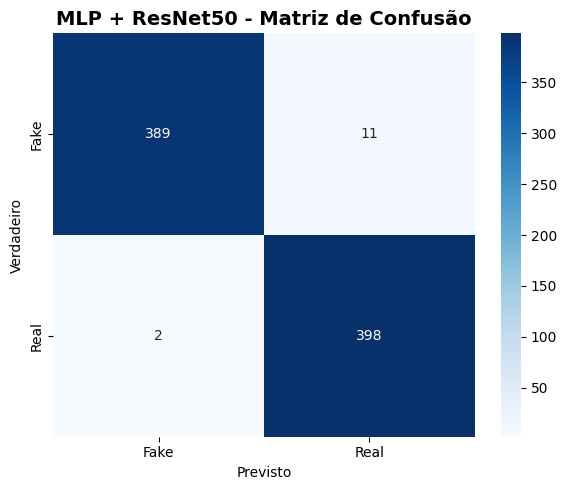

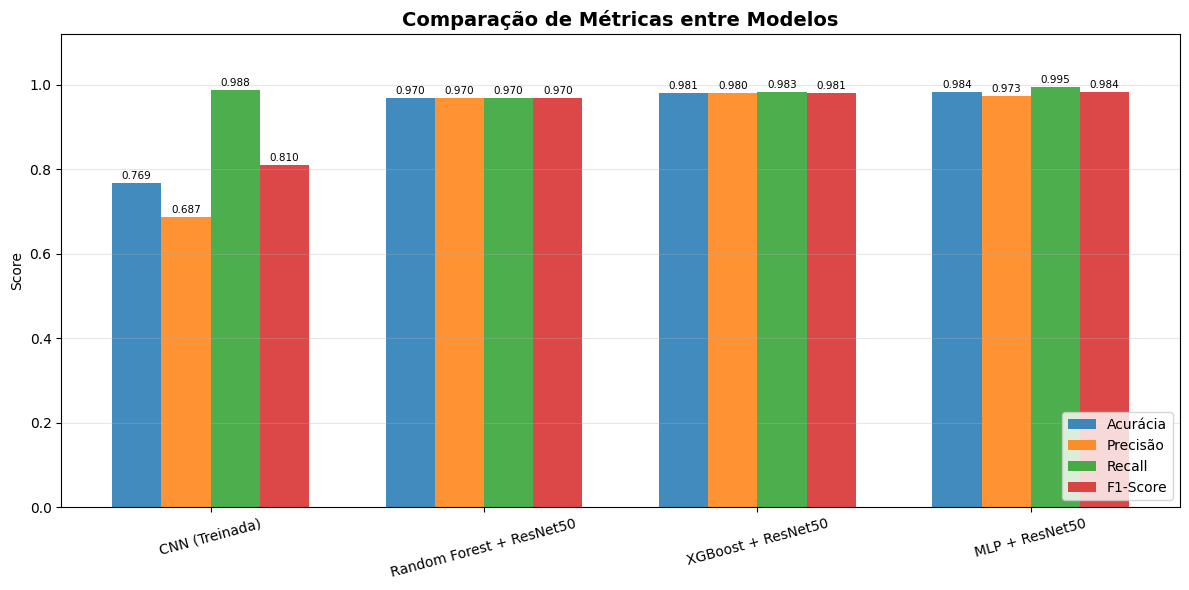

Gráfico de barras salvo como 'metricas_comparacao.png'


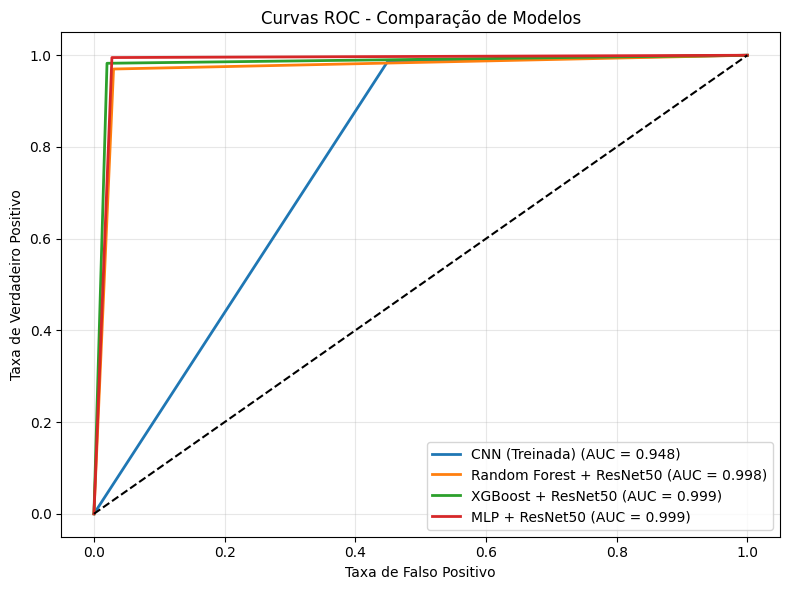

In [30]:
# Definição dos modelos
model_names = ["CNN (Treinada)", "Random Forest + ResNet50", "XGBoost + ResNet50", "MLP + ResNet50"]

# 1. Curva de aprendizado da CNN
plt.figure(figsize=(10, 6))
epochs = range(1, len(history_cnn.history['accuracy']) + 1)
plt.plot(epochs, history_cnn.history['accuracy'], 'b-o', label='Treino Acc')
plt.plot(epochs, history_cnn.history['val_accuracy'], 'r-o', label='Validação Acc')
plt.plot(epochs, history_cnn.history['loss'], 'b--', label='Treino Loss', alpha=0.6)
plt.plot(epochs, history_cnn.history['val_loss'], 'r--', label='Validação Loss', alpha=0.6)
plt.title('CNN - Curva de Aprendizado', fontweight='bold', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Valor')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Curva de aprendizado salva como 'cnn_learning_curve.png'")

# 2. Matrizes de confusão
cms = [metrics_cnn["cm"], metrics_rf["cm"], metrics_xgb["cm"], metrics_mlp["cm"]]
for name, cm in zip(model_names, cms):
    plot_confusion_matrix(name, cm)

# 3. Comparação de métricas (barras)
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

x = np.arange(len(model_names))
width = 0.18

plt.figure(figsize=(12, 6))
for j, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    values = [results[m][metric] for m in model_names]
    bars = plt.bar(x + j * width, values, width, label=label, alpha=0.85)
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha='center', va='bottom', fontsize=7.5)

plt.title('Comparação de Métricas entre Modelos', fontweight='bold', fontsize=14)
plt.xticks(x + width * 1.5, model_names, fontsize=10, rotation=15)
plt.ylim(0, 1.12)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metricas_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico de barras salvo como 'metricas_comparacao.png'")

# 4. Curvas ROC
plt.figure(figsize=(8,6))
for name in model_names:
    if 'auc' in results[name]:
        fpr, tpr, _ = roc_curve(y_test_cnn if 'CNN' in name else y_test_resnet,
                                results[name].get('y_prob', results[name]['y_pred']))
        auc = results[name]['auc']
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curvas ROC - Comparação de Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [31]:
print("\n" + "="*80)
print("RESUMO FINAL - COMPARAÇÃO DE MODELOS")
print("="*80)
print(f"{'Modelo':<30} {'Acurácia':>10} {'Precisão':>10} {'Recall':>10} {'F1-Score':>10} {'AUC':>10}")
print("-"*80)
for name in model_names:
    m = results[name]
    auc_str = f"{m['auc']:.4f}" if 'auc' in m else "N/A"
    print(f"{name:<30} {m['accuracy']:>10.4f} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f} {auc_str:>10}")
print("="*80)

best_model_f1 = max(model_names, key=lambda n: results[n]['f1'])
best_model_auc = max(model_names, key=lambda n: results[n].get('auc',0))
print(f"\nMelhor modelo (F1-Score): {best_model_f1} (F1 = {results[best_model_f1]['f1']:.4f})")
print(f"Melhor AUC: {best_model_auc} (AUC = {results[best_model_auc]['auc']:.4f})")


RESUMO FINAL - COMPARAÇÃO DE MODELOS
Modelo                           Acurácia   Precisão     Recall   F1-Score        AUC
--------------------------------------------------------------------------------
CNN (Treinada)                     0.7688     0.6870     0.9875     0.8103     0.9478
Random Forest + ResNet50           0.9700     0.9700     0.9700     0.9700     0.9975
XGBoost + ResNet50                 0.9812     0.9800     0.9825     0.9813     0.9989
MLP + ResNet50                     0.9838     0.9731     0.9950     0.9839     0.9992

Melhor modelo (F1-Score): MLP + ResNet50 (F1 = 0.9839)
Melhor AUC: MLP + ResNet50 (AUC = 0.9992)


## 7. Deployment
Os modelos podem ser salvos para uso futuro:

In [ ]:
# Salvar modelos
joblib.dump(rf_resnet, "random_forest_resnet50_deepfake.pkl")
joblib.dump(xgb_resnet, "xgboost_resnet50_deepfake.pkl")
joblib.dump(mlp_resnet, "mlp_resnet50_deepfake.pkl")

# Salvar a CNN
cnn.save("cnn_deepfake.keras")

print("Modelos salvos com sucesso!")